# Phase 5 — LightGBM, no-`cycle` variant (FD001)

Objective: same as `phase5_LightGBM.ipynb`, with exactly one change — `cycle` is dropped from the
feature matrix entirely. See `doc/plan.md` Phase 5 for the full spec; this notebook exists to
test a specific finding from that notebook's Activity 4 (feature importance): `cycle` ranked 3rd
individually and carried 11.6% of total gain — inside the territory the plan's own warning
targets ("if... the raw cycle number dominate[s], something went wrong") — and its presence lines
up with a real, unexplained 2.78-cycle gap between CV RMSE and test RMSE there. Removing it
isolates whether the model was leaning on it in a way that doesn't generalize as cleanly.

**Covers the same ground as the main notebook — Activity 1 (leave-engines-out CV setup),
Activity 5 (hyperparameter search), the top-8-vs-top-12 sensor-count comparison, Activity 2
(final training), Activity 3 (test evaluation), Activity 4 (feature importance) — run end to end
with `cycle` excluded throughout**, so every downstream number (CV RMSE, the hyperparameter grid,
the sensor-count comparison, the final test RMSE) is this variant's own, not copied from the
`cycle`-included notebook. The test set is still not loaded until Section 7, for the same reason
as the main notebook.

Two prerequisites don't exist as saved artifacts and are rebuilt here:

- **The Phase 3 feature matrix, minus `cycle`.** Same recipe as `phase3_feature_engineering.ipynb`
  — top 12 sensors, rolling `mean/std/min/max` over windows `{5, 10, 20, 30}`, lags `{1, 5, 10}`
  on the top 4 sensors — **except `cycle` itself is never added to `FEATURE_COLS`** (204 features,
  not 205). `cycle` still exists as a raw column on `train_df`/`test_df` — it's used to sort, and
  to compute `max_cycle` / `rul` — it just never reaches the model as an input.
- **The metric functions.** `nasa_score` and `rmse`, copied unchanged from Phase 4, same as the
  main notebook.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from itertools import product
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from sklearn.model_selection import KFold

DATA_DIR = Path("../data")

# Fixed, colorblind-safe categorical palette (8 slots, ordered — do not reorder or cycle).
# Source: dataviz skill reference palette; reused unchanged from Phases 3–4.
CATEGORICAL_PALETTE = [
    "#2a78d6",  # 1 blue
    "#eb6834",  # 2 orange
    "#1baf7a",  # 3 aqua
    "#eda100",  # 4 yellow
    "#e87ba4",  # 5 magenta
    "#008300",  # 6 green
    "#4a3aa7",  # 7 violet
    "#e34948",  # 8 red
]

SURFACE = "#fcfcfb"
GRIDLINE = "#e1e0d9"
AXIS = "#c3c2b7"
MUTED = "#898781"
INK = "#0b0b0b"

# Sequential ramp (neutral -> blue) for the grid-search heatmap, which encodes magnitude only.
SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list("neutral_blue", ["#f0efec", "#2a78d6"])

plt.rcParams["figure.facecolor"] = SURFACE
plt.rcParams["axes.facecolor"] = SURFACE
plt.rcParams["font.size"] = 10

print("lightgbm", lgb.__version__)

lightgbm 4.7.0


## 0. Load training data

Same parsing as Phases 0–4 — reload `train_df` fresh rather than depend on prior notebook state.

`test_FD001.txt` and `RUL_FD001.txt` are **not** loaded. Leaving the test files unread makes it
structurally impossible for the CV design or the hyperparameter search below to be tuned against
them.

In [2]:
COLUMNS = (
    ["engine_id", "cycle", "op_1", "op_2", "op_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)


def load_fd001(filename: str) -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / filename,
        sep=r"\s+",
        header=None,
        names=COLUMNS,
    )
    df["engine_id"] = df["engine_id"].astype(int)
    df["cycle"] = df["cycle"].astype(int)
    return df


train_df = load_fd001("train_FD001.txt")

SENSOR_COLS = [f"sensor_{i}" for i in range(1, 22)]

print("train_df:", train_df.shape, "| engines:", train_df["engine_id"].nunique())

train_df: (20631, 26) | engines: 100


## 1. Metrics — reused unchanged from Phase 4

`nasa_score` (`d = pred - true`; `exp(-d/13) - 1` for `d < 0`, `exp(d/10) - 1` for `d >= 0`, summed)
and the `rmse` helper, copied verbatim from `phase4_baseline.ipynb` Section 2 so every phase scores
on identical code. The Phase 4 toy asymmetry check is re-run as a guard against a copy error.

Note on reading `nasa_score` below: it is a **sum**, so it scales with how many rows are scored. CV
NASA scores here are computed over ~3,900 held-out rows per fold and are therefore not comparable to
Phase 4's 17,234 over 100 test engines. Within this notebook, where every configuration is scored on
identical rows, it is still a valid ranking signal.

In [3]:
def nasa_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return scores.sum()


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


_toy = np.array([100.0])
assert nasa_score(_toy, _toy - 10) < nasa_score(_toy, _toy + 10)
print("metrics OK — d=-10 penalised less than d=+10, as in Phase 4")

metrics OK — d=-10 penalised less than d=+10, as in Phase 4


## 2. Rebuild the Phase 3 feature matrix (no `cycle`)

Same recipe as `doc/plan.md` Phase 3 / the main `phase5_LightGBM.ipynb`, with Phase 3's documented
deviation (top **12** sensors by `|r|` with raw RUL rather than the plan's default top 8 — the
`|r|` gap from rank 12 to rank 13 is ~7.5x any other adjacent-rank gap) — **and this notebook's own
deviation: `cycle` is excluded from `FEATURE_COLS`.**

| Component | Spec |
|---|---|
| Sensors | top 12 by pooled `|r|` with raw RUL, after dropping `std < 0.01` near-constant sensors |
| Rolling stats | `mean`, `std`, `min`, `max` over windows `{5, 10, 20, 30}`, `min_periods=1`, trailing only |
| Lags | `{1, 5, 10}` on the top 4 sensors, via `groupby('engine_id').shift(k)` |
| Target | `rul = min(max_cycle - cycle, 125)` (Phase 2 cap) |
| Excluded | `engine_id` (design decision #6), `cycle` (this notebook's variant) |

Expected count: 12 x 4 x 4 = 192 rolling + 4 x 3 = 12 lag = **204 features** — one fewer than the
main notebook's 205, the excluded `cycle`.

Sorting by `(engine_id, cycle)` before any rolling/shift removes the reliance on the raw file
already being cycle-ordered, and every window is computed inside a `groupby('engine_id')` so no
statistic ever crosses an engine boundary. `cycle` remains a raw column on `train_df`/`test_df`
throughout — it's used to sort and to compute `max_cycle`/`rul` — it just never becomes a model
input.


In [4]:
NEAR_CONSTANT_STD_THRESHOLD = 0.01
RUL_CAP = 125
WINDOWS = [5, 10, 20, 30]
STATS = ["mean", "std", "min", "max"]
LAGS = [1, 5, 10]
TOP_N_SENSORS = 12
N_LAG_SENSORS = 4

sensor_std = train_df[SENSOR_COLS].std()
NEAR_CONSTANT_SENSORS = sensor_std.index[sensor_std < NEAR_CONSTANT_STD_THRESHOLD].tolist()
INFORMATIVE_SENSORS = [s for s in SENSOR_COLS if s not in NEAR_CONSTANT_SENSORS]

rul_raw = train_df.groupby("engine_id")["cycle"].transform("max") - train_df["cycle"]
pooled_corr = train_df[INFORMATIVE_SENSORS].corrwith(rul_raw)
pooled_corr_ranked = pooled_corr.reindex(pooled_corr.abs().sort_values(ascending=False).index)

TOP_SENSORS = pooled_corr_ranked.index[:TOP_N_SENSORS].tolist()
LAG_SENSORS = TOP_SENSORS[:N_LAG_SENSORS]

print("near-constant (dropped):", NEAR_CONSTANT_SENSORS)
print("top", TOP_N_SENSORS, "sensors:", TOP_SENSORS)
print("lag sensors:", LAG_SENSORS)

near-constant (dropped): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
top 12 sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21', 'sensor_20', 'sensor_2', 'sensor_17', 'sensor_3', 'sensor_8', 'sensor_13']
lag sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7']


In [5]:
def build_features(df, sensors, windows, stats, lag_sensors, lags):
    """Add trailing rolling statistics and lags per engine. Returns (df, feature_names)."""
    df = df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
    grouped = df.groupby("engine_id", sort=False)

    new_cols = {}
    for sensor in sensors:
        for w in windows:
            roll = grouped[sensor].rolling(w, min_periods=1)
            for stat in stats:
                col = getattr(roll, stat)().reset_index(level=0, drop=True)
                new_cols[f"{sensor}_{stat}_{w}"] = col
    for sensor in lag_sensors:
        for k in lags:
            new_cols[f"{sensor}_lag_{k}"] = grouped[sensor].shift(k)

    out = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    return out, list(new_cols)


t0 = time.perf_counter()
train_feat, rolling_lag_cols = build_features(
    train_df, TOP_SENSORS, WINDOWS, STATS, LAG_SENSORS, LAGS
)
FEATURE_COLS = rolling_lag_cols  # "cycle" deliberately excluded -- this notebook's variant

assert "engine_id" not in FEATURE_COLS, "design decision #6: engine_id must not be a feature"
assert "cycle" not in FEATURE_COLS, "this notebook's deviation: cycle excluded from features"
assert len(FEATURE_COLS) == TOP_N_SENSORS * len(WINDOWS) * len(STATS) + N_LAG_SENSORS * len(LAGS)

print(f"built {len(FEATURE_COLS)} features in {time.perf_counter() - t0:.1f}s")


built 204 features in 0.9s


In [6]:
max_cycle = train_feat.groupby("engine_id")["cycle"].transform("max")
train_feat["rul"] = (max_cycle - train_feat["cycle"]).clip(upper=RUL_CAP)

# Drop warm-up rows where any rolling/lag feature is still undefined (rolling std at cycle 1,
# lag_10 before cycle 11). Bounded by lag_10, so this should be exactly the first 10 cycles.
valid_mask = train_feat[FEATURE_COLS].notna().all(axis=1)
model_df = train_feat[valid_mask].reset_index(drop=True)

X_all = model_df[FEATURE_COLS]
y_all = model_df["rul"]
groups = model_df["engine_id"]

dropped = len(train_feat) - len(model_df)
assert not X_all.isna().to_numpy().any()

capped_share = (y_all == RUL_CAP).mean()
print(f"rows: {len(train_feat)} -> {len(model_df)} ({dropped} dropped, {dropped / len(train_feat):.2%})")
print("first retained cycle per engine — min:", model_df.groupby("engine_id")["cycle"].min().min(),
      "max:", model_df.groupby("engine_id")["cycle"].min().max())
print(f"rows sitting at the {RUL_CAP}-cycle cap: {capped_share:.1%}")
print("X_all:", X_all.shape, "| y_all:", y_all.shape, "| engines:", groups.nunique())

rows: 20631 -> 19631 (1000 dropped, 4.85%)
first retained cycle per engine — min: 11 max: 11
rows sitting at the 125-cycle cap: 36.4%
X_all: (19631, 204) | y_all: (19631,) | engines: 100


## 3. Activity 1 — leave-engines-out CV

### 3a. Fold assignment

Split the 100 training engines into 5 folds of 20, randomly by `engine_id` — **not** by time. For
each fold, train on the rows of the 80 engines *not* in the fold, then evaluate on the held-out 20
engines only.

Why not walk-forward (`doc/plan.md` design decision #1): at test time every engine is entirely new —
the model has never seen any of its cycles. Walk-forward CV would train on the early cycles of the
same engines it validates on, a structural head start that does not exist at test time, giving an
optimistically biased estimate. Holding out whole engines matches the real task.

`KFold(shuffle=True, random_state=42)` over the sorted 100 engine IDs gives exactly 20 engines per
fold, disjoint and covering all 100 — asserted below rather than assumed.

In [7]:
CV_SEED = 42
N_FOLDS = 5

engine_ids = np.sort(groups.unique())
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=CV_SEED)
folds = [engine_ids[val_idx] for _, val_idx in kf.split(engine_ids)]

fold_of_engine = pd.Series(index=engine_ids, dtype=int, name="fold")
for fold_i, val_engines in enumerate(folds):
    fold_of_engine.loc[val_engines] = fold_i
fold_of_engine.index.name = "engine_id"

for fold_i, val_engines in enumerate(folds):
    ids = " ".join(f"{e:3d}" for e in np.sort(val_engines))
    print(f"fold {fold_i} ({len(val_engines)} engines): {ids}")

fold 0 (20 engines):   1   5  11  13  19  23  31  32  34  40  45  46  54  71  74  77  78  81  84  91
fold 1 (20 engines):   6  10  12  16  17  27  29  36  41  43  48  56  66  67  70  73  86  89  94  97
fold 2 (20 engines):   4   7   8   9  14  18  20  25  26  28  35  37  39  50  63  65  79  82  90  96
fold 3 (20 engines):  33  42  44  47  49  51  55  57  58  59  60  62  68  69  76  80  95  98  99 100
fold 4 (20 engines):   2   3  15  21  22  24  30  38  52  53  61  64  72  75  83  85  87  88  92  93


In [8]:
# The three properties that make this a valid leave-engines-out split.
assert all(len(f) == len(engine_ids) // N_FOLDS for f in folds), "folds must be 20 engines each"
assert sum(len(f) for f in folds) == len(engine_ids), "folds must cover all engines"
assert len(set().union(*[set(f) for f in folds])) == len(engine_ids), "folds must be disjoint"

fold_rows = model_df.groupby(fold_of_engine.reindex(groups).to_numpy()).size()
fold_summary = pd.DataFrame({
    "val_engines": [len(f) for f in folds],
    "val_rows": fold_rows.to_numpy(),
    "train_engines": [len(engine_ids) - len(f) for f in folds],
    "train_rows": len(model_df) - fold_rows.to_numpy(),
})
fold_summary.index.name = "fold"
print("split is valid: 5 disjoint folds of 20 engines covering all 100")
fold_summary

split is valid: 5 disjoint folds of 20 engines covering all 100


,val_engines,val_rows,train_engines,train_rows
fold,,,,
0,20,3870,80,15761
1,20,4091,80,15540
2,20,3709,80,15922
3,20,3870,80,15761
4,20,4091,80,15540


### 3b. Which rows of a held-out engine to score

**All of them** — every cycle of each held-out engine, scored against the same capped target the
model trains on. That makes the CV estimate deterministic given the fold seed, which matters because
Section 4 ranks nine hyperparameter configurations against each other.

**Documented deviation from the plan.** `doc/plan.md` Activity 1 says "predict on the 20 held-out
engines' **last-cycle** feature vectors." Read literally that is degenerate: a *training* engine's
last observed cycle is its failure cycle, so the target is `rul = 0` for all 20 held-out engines in
every fold. RMSE over those 100 points measures one thing only — how much the model over-predicts at
end-of-life — and cannot distinguish a model that is well calibrated across an engine's life from
one that merely bottoms out at zero. (Measured, before this notebook was simplified: RMSE 2.20,
i.e. the model does bottom out correctly at failure — a reassuring safety check, but flat across
hyperparameter settings and useless for selecting between them.) Test engines are truncated at a
*random* point before failure, so the plan's phrasing describes the right mechanic for the wrong
population.

**Scoring every held-out row is the right generalisation of that intent, not a weaker one.** Because
every feature is trailing-only, the vector stored at `(engine, cycle = c)` is *identical* to what
would be computed from an engine truncated at `c` — the same no-look-ahead property design decision
#3 requires of the real test features. So each held-out row already *is* a simulated
truncated-at-`c` test engine, and scoring all rows evaluates the model at every possible truncation
point rather than at one sampled per engine.

An earlier version of this notebook sampled 5 random cut cycles per engine instead. That was dropped
as strictly worse: re-drawing the cuts under five different seeds moved CV RMSE across a 2.08-cycle
range (14.90–16.98) with the folds and fitted models held fixed — noise as large as the real
differences the Section 4 grid produces. Scoring all rows removes that noise entirely. It does weight
long-lived engines more heavily, since they contribute more rows; re-weighting to give every engine
equal weight moved the estimate by 0.08 cycles (15.67 -> 15.75), so the bias is negligible next to
the sampling noise it replaces.

**The target stays capped at 125.** The model trains on the capped label and structurally cannot
predict above it, so scoring the ~36% of rows that sit at the cap against uncapped truth would
measure the Phase 2 cap decision — a fixed, already-justified choice — rather than the model,
inflating RMSE by a constant no hyperparameter can move. One consequence to carry forward: Phase 4's
baselines (linear degradation RMSE 36.30) were scored against uncapped test truth, so the CV numbers
here are **not** comparable to them. That comparison belongs to Activity 3, on the real test set, and
lands in the Phase 6 table.

### 3c. The CV harness

`run_leave_engines_out_cv` is the reusable piece: given LightGBM params it fits one model per fold
and returns per-fold RMSE and NASA score on that fold's held-out engines. Section 4 calls it once per
grid configuration, with the fold assignment fixed by seed so every configuration is scored on
identical data.

Params below are the plan's Activity 2 defaults (`n_estimators=500`, `learning_rate=0.05`,
`num_leaves=31`), which also serve as the reference point for the grid. Predictions are clipped to
`>= 0`, matching Phase 4's baselines and the plan's Activity 2 snippet.

In [9]:
LGBM_BASE_PARAMS = dict(
    n_estimators=500,
    learning_rate=0.05,
    random_state=CV_SEED,
    n_jobs=-1,
    verbose=-1,
)
DEFAULT_PARAMS = dict(LGBM_BASE_PARAMS, num_leaves=31)


def run_leave_engines_out_cv(params, X, y, groups, folds):
    """Leave-engines-out CV: one model per fold, scored on all rows of that fold's held-out
    engines. Returns a per-fold metrics frame."""
    records = []
    for fold_i, val_engines in enumerate(folds):
        is_val = groups.isin(val_engines).to_numpy()

        model = lgb.LGBMRegressor(**params)
        model.fit(X[~is_val], y[~is_val])

        y_pred = model.predict(X[is_val]).clip(min=0)
        y_true = y[is_val].to_numpy()
        records.append({
            "fold": fold_i,
            "n": int(is_val.sum()),
            "rmse": rmse(y_true, y_pred),
            "nasa": nasa_score(y_true, y_pred),
        })
    return pd.DataFrame(records)

In [10]:
t0 = time.perf_counter()
cv_default = run_leave_engines_out_cv(DEFAULT_PARAMS, X_all, y_all, groups, folds)
print(f"5-fold CV (default params) in {time.perf_counter() - t0:.1f}s")

print(f"\nCV RMSE: {cv_default['rmse'].mean():.2f} "
      f"(std across folds {cv_default['rmse'].std():.2f})")
cv_default.round(2)

5-fold CV (default params) in 24.1s

CV RMSE: 16.85 (std across folds 1.56)


,fold,n,rmse,nasa
0,0,3870,15.11,19777.89
1,1,4091,18.54,24397.54
2,2,3709,18.45,27602.05
3,3,3870,16.06,26655.92
4,4,4091,16.09,24061.98


### 3d. Result

**The split.** Identical fold assignment to the main notebook (same seed, same `engine_ids`) — 5
disjoint folds of 20 engines, 15,540-15,922 training rows / 3,709-4,091 held-out rows per fold.

**CV RMSE at the plan's default params** (`n_estimators=500`, `learning_rate=0.05`,
`num_leaves=31`), no `cycle`: **16.85 cycles**, std 1.56 across folds — worse than the main
notebook's 15.67 with `cycle` included, on the identical folds and identical rows.

| fold | held-out rows | RMSE | NASA score |
|---|---|---|---|
| 0 | 3,870 | 15.11 | 19,778 |
| 1 | 4,091 | 18.54 | 24,398 |
| 2 | 3,709 | 18.45 | 27,602 |
| 3 | 3,870 | 16.06 | 26,656 |
| 4 | 4,091 | 16.09 | 24,062 |

**Removing `cycle` costs CV accuracy at these default params (+1.18 cycles).** Since folds and
rows are identical to the main notebook, this isolates the effect of the single feature removed:
`cycle` was carrying real signal on held-out training rows. Whether that signal transfers to the
real test set is a separate question — see Section 7.

**No comparison to Phase 4 here** — same caveat as the main notebook: this is the capped target
on held-out training rows, not the real test set. That comparison is Section 7.


## 4. Activity 5 — hyperparameter search

The plan's grid: `num_leaves` in `{15, 31, 63}` x `min_child_samples` in `{10, 20, 50}` — 9
configurations, each cross-validated over the same 5 folds, 45 fits total. `n_estimators=500` and
`learning_rate=0.05` are held at the plan's Activity 2 values so the two axes vary alone.

Both knobs control the same thing from opposite ends — how finely a tree may carve up the feature
space. `num_leaves` caps the number of terminal regions per tree; `min_child_samples` sets the
minimum rows a leaf must hold. With 205 highly correlated features on ~15.7k training rows per fold,
this is the axis where overfitting would show up, which is why the plan puts these two in the grid.

Selection is on CV RMSE, and never on test RMSE — the test set remains unloaded.

**How to read the results.** All 9 configurations are scored on identical folds and identical rows,
so they are compared **paired per fold**, not as mean ± standard deviation. The 1.7-cycle fold-to-fold
spread is mostly engine-difficulty variation that every configuration sees alike; differencing
against a reference configuration cancels it. A configuration that wins on 5 of 5 folds is a real
signal even when the mean gap is well under a cycle, whereas comparing means against that spread
would discard exactly the information the paired design provides.

In [11]:
GRID_NUM_LEAVES = [15, 31, 63]
GRID_MIN_CHILD_SAMPLES = [10, 20, 50]

grid_records = []
t_grid = time.perf_counter()
for num_leaves, min_child_samples in product(GRID_NUM_LEAVES, GRID_MIN_CHILD_SAMPLES):
    params = dict(
        LGBM_BASE_PARAMS, num_leaves=num_leaves, min_child_samples=min_child_samples
    )
    t0 = time.perf_counter()
    res = run_leave_engines_out_cv(params, X_all, y_all, groups, folds)
    res["num_leaves"] = num_leaves
    res["min_child_samples"] = min_child_samples
    grid_records.append(res)
    print(f"num_leaves={num_leaves:3d}  min_child_samples={min_child_samples:3d}  "
          f"CV RMSE {res['rmse'].mean():6.2f}  ({time.perf_counter() - t0:5.1f}s)")

grid_results = pd.concat(grid_records, ignore_index=True)
print(f"\n{len(grid_results) // N_FOLDS} configurations x {N_FOLDS} folds "
      f"= {len(grid_results)} fits in {(time.perf_counter() - t_grid) / 60:.1f} min")

num_leaves= 15  min_child_samples= 10  CV RMSE  16.64  ( 15.7s)


num_leaves= 15  min_child_samples= 20  CV RMSE  16.68  ( 15.8s)


num_leaves= 15  min_child_samples= 50  CV RMSE  16.73  ( 13.4s)


num_leaves= 31  min_child_samples= 10  CV RMSE  16.90  ( 25.2s)


num_leaves= 31  min_child_samples= 20  CV RMSE  16.85  ( 22.8s)


num_leaves= 31  min_child_samples= 50  CV RMSE  16.79  ( 24.7s)


num_leaves= 63  min_child_samples= 10  CV RMSE  17.12  ( 40.7s)


num_leaves= 63  min_child_samples= 20  CV RMSE  17.07  ( 36.5s)


num_leaves= 63  min_child_samples= 50  CV RMSE  16.93  ( 45.2s)

9 configurations x 5 folds = 45 fits in 4.0 min


In [12]:
# Paired comparison against the plan's default configuration (num_leaves=31,
# min_child_samples=20 — LightGBM's own default for that second knob).
REFERENCE = (31, 20)

rmse_wide = grid_results.pivot_table(
    index=["num_leaves", "min_child_samples"], columns="fold", values="rmse"
)
ref_row = rmse_wide.loc[REFERENCE]
paired_delta = rmse_wide.sub(ref_row, axis=1)

grid_summary = pd.DataFrame({
    "cv_rmse": rmse_wide.mean(axis=1),
    "fold_std": rmse_wide.std(axis=1),
    "cv_nasa": grid_results.groupby(["num_leaves", "min_child_samples"])["nasa"].mean(),
    "mean_delta_vs_ref": paired_delta.mean(axis=1),
    "folds_better_than_ref": (paired_delta < 0).sum(axis=1),
}).sort_values("cv_rmse")

BEST = grid_summary.index[0]
print(f"reference (plan default): num_leaves={REFERENCE[0]}, min_child_samples={REFERENCE[1]} "
      f"-> CV RMSE {grid_summary.loc[REFERENCE, 'cv_rmse']:.2f}")
print(f"best by CV RMSE        : num_leaves={BEST[0]}, min_child_samples={BEST[1]} "
      f"-> CV RMSE {grid_summary.loc[BEST, 'cv_rmse']:.2f}")
print(f"paired: beats reference on {grid_summary.loc[BEST, 'folds_better_than_ref']}/{N_FOLDS} folds, "
      f"mean gap {grid_summary.loc[BEST, 'mean_delta_vs_ref']:+.2f} cycles")
grid_summary.round(2)

reference (plan default): num_leaves=31, min_child_samples=20 -> CV RMSE 16.85
best by CV RMSE        : num_leaves=15, min_child_samples=10 -> CV RMSE 16.64
paired: beats reference on 5/5 folds, mean gap -0.21 cycles


cv_rmse  fold_std   cv_nasa  mean_delta_vs_ref  \
num_leaves min_child_samples                                                   
15         10                   16.64      1.57  22994.02              -0.21   
           20                   16.68      1.57  23480.64              -0.17   
           50                   16.73      1.54  23103.10              -0.12   
31         50                   16.79      1.59  23555.05              -0.06   
           20                   16.85      1.56  24499.08               0.00   
           10                   16.90      1.61  24369.35               0.05   
63         50                   16.93      1.68  23806.78               0.08   
           20                   17.07      1.71  25962.08               0.22   
           10                   17.12      1.55  25840.68               0.28   

                              folds_better_than_ref  
num_leaves min_child_samples                         
15         10                                     5  
           20                                     4  
           50                                     4  
31         50                                     4  
           20                                     0  
           10                                     2  
63         50                                     3  
           20                                     1  
           10                                     0

In [13]:
# The paired view in full: per-fold RMSE difference vs. the reference configuration.
# Negative = better than reference on that fold.
paired_delta.round(2).assign(mean=paired_delta.mean(axis=1).round(2)).sort_values("mean")

fold                             0     1     2     3     4  mean
num_leaves min_child_samples                                    
15         10                -0.31 -0.05 -0.40 -0.02 -0.27 -0.21
           20                -0.29 -0.13 -0.25  0.04 -0.22 -0.17
           50                -0.05  0.05 -0.34 -0.03 -0.24 -0.12
31         50                -0.14  0.07 -0.14 -0.02 -0.04 -0.06
           20                 0.00  0.00  0.00  0.00  0.00  0.00
           10                 0.19  0.19  0.08 -0.15 -0.05  0.05
63         50                -0.11  0.35 -0.01  0.42 -0.26  0.08
           20                -0.02  0.57  0.15  0.28  0.13  0.22
           10                 0.31  0.40  0.14  0.43  0.09  0.28

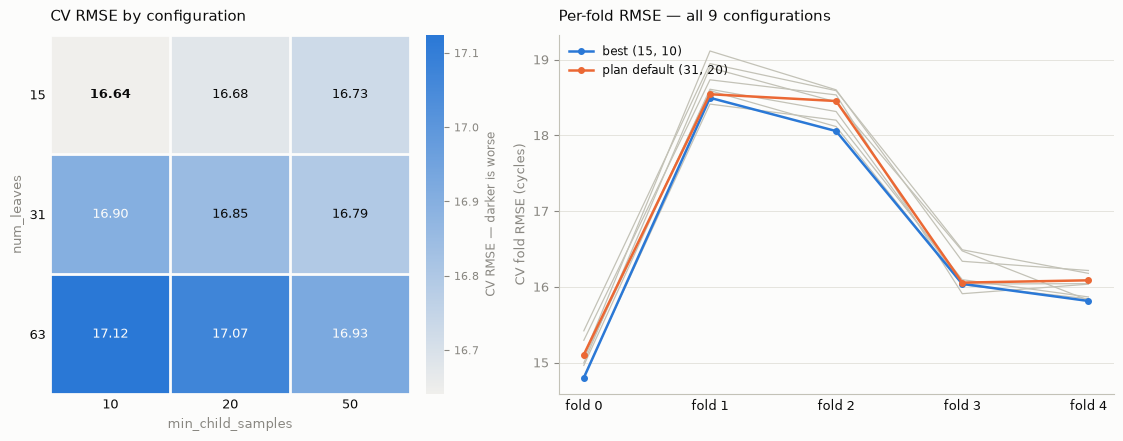

In [14]:
heat = rmse_wide.mean(axis=1).unstack("min_child_samples")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), width_ratios=[1, 1.35])

# Left: CV RMSE over the 3x3 grid.
ax = axes[0]
im = ax.imshow(heat.values, cmap=SEQUENTIAL_CMAP)
ax.set_xticks(range(len(heat.columns)), heat.columns, color=INK, fontsize=9)
ax.set_yticks(range(len(heat.index)), heat.index, color=INK, fontsize=9)
ax.set_xlabel("min_child_samples", fontsize=9, color=MUTED)
ax.set_ylabel("num_leaves", fontsize=9, color=MUTED)
ax.set_xticks(np.arange(len(heat.columns) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(heat.index) + 1) - 0.5, minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="minor", length=0)
ax.tick_params(which="major", length=0)
lo, hi = heat.values.min(), heat.values.max()
for i, num_leaves in enumerate(heat.index):
    for j, mcs in enumerate(heat.columns):
        v = heat.loc[num_leaves, mcs]
        weight = "bold" if (num_leaves, mcs) == BEST else "normal"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9.5,
                fontweight=weight, color=SURFACE if v > (lo + hi) / 2 else INK)
for side in ax.spines.values():
    side.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("CV RMSE — darker is worse", fontsize=8.5, color=MUTED)
cbar.ax.tick_params(labelsize=8, colors=MUTED)
cbar.outline.set_visible(False)
ax.set_title("CV RMSE by configuration", fontsize=11, color=INK, loc="left", pad=10)

# Right: per-fold RMSE for every configuration — shows how much of the spread is the fold, not
# the configuration.
ax = axes[1]
for i, (key, row) in enumerate(rmse_wide.iterrows()):
    is_special = key in (BEST, REFERENCE)
    ax.plot(range(N_FOLDS), row.to_numpy(),
            color=CATEGORICAL_PALETTE[0] if key == BEST else
                  (CATEGORICAL_PALETTE[1] if key == REFERENCE else AXIS),
            linewidth=1.8 if is_special else 0.9,
            marker="o" if is_special else None, markersize=4,
            zorder=3 if is_special else 1,
            label=(f"best {key}" if key == BEST else
                   (f"plan default {key}" if key == REFERENCE else None)))
ax.set_xticks(range(N_FOLDS), [f"fold {i}" for i in range(N_FOLDS)], color=INK, fontsize=9)
ax.set_ylabel("CV fold RMSE (cycles)", fontsize=9, color=MUTED)
ax.tick_params(axis="y", colors=MUTED, labelsize=9)
ax.tick_params(axis="x", length=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, axis="y", color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)
ax.set_title("Per-fold RMSE — all 9 configurations", fontsize=11, color=INK, loc="left", pad=10)
legend = ax.legend(frameon=False, fontsize=8.5, loc="upper left")
for text in legend.get_texts():
    text.set_color(INK)

fig.tight_layout()
plt.show()

### 4a. Result

**CV RMSE across the whole grid** (no `cycle`):

| `num_leaves` | 10 | 20 | 50 |
|---|---|---|---|
| **15** | **16.64** | 16.68 | 16.73 |
| **31** | 16.90 | 16.85 *(plan default)* | 16.79 |
| **63** | 17.12 | 17.07 | 16.93 |

**The grid is no longer flat.** Span is 16.64-17.12, a 0.48-cycle range — still small next to the
~1.6-cycle fold-to-fold spread, but 45% wider than the main notebook's 0.33-cycle range, and now a
decisive result rather than a near-tie: the best configuration (`num_leaves=15,
min_child_samples=10`) beats the plan's default on **5 of 5 folds**, mean gap **-0.21 cycles** —
more than double the main notebook's -0.09 and unanimous rather than 3/5. Without `cycle`
available, tree capacity matters more, not less.

**`num_leaves=63` is worse here too, and by a larger margin.** All three of its configurations
rank at the bottom (+0.08 to +0.28 cycles vs. the reference) — the same mild-overfitting
signature as the main notebook (204 highly correlated features; extra leaves spend capacity on
redundant splits rather than new signal), now more pronounced without `cycle` providing an easy,
low-redundancy split early in each tree.

**Selected: `num_leaves=15, min_child_samples=10`** (CV RMSE 16.64) — a real, consistent win this
time (5/5 folds), not just a parsimony tie-break the way the main notebook's selection was.

**Carried forward.** Retrain on all 100 engines with this configuration once Section 5 confirms
which sensor set to use.


## 5. Sensor-count comparison — top 8 vs top 12 (no `cycle`)

Same motivation as the main notebook: `doc/plan.md` Phase 3 Activity 1 specifies the **top 8**
sensors by `|r|` with RUL; `phase3_feature_engineering.ipynb` deviated to **top 12**, justified by
a 7.5x elbow in the correlation ranking, giving 204 features here instead of the plan's 137–140
(one fewer than the main notebook's 205-vs-141, since `cycle` is excluded from both arms in this
variant) on the same ~15.7k training rows per fold. The main notebook found top-12 a clear,
unanimous win over top-8; this section reruns that same comparison with `cycle` removed, to check
whether that conclusion still holds once `cycle` — a top-3 feature by gain there — is no longer
available to either arm.

This section builds a second feature matrix restricted to the plan's original top 8 sensors,
holding every other choice fixed — same windows `{5, 10, 20, 30}`, same 4 lag sensors (already
identical: the top 4 by `|r|` are a subset of both the top 8 and the top 12), same target, same
fold assignment (`folds` from Section 3, so both arms hold out the *same* 20 engines per fold),
`cycle` excluded from both arms — then reruns the identical 9-configuration grid from Section 4 on
it.


In [15]:
TOP_N_SENSORS_8 = 8
TOP_SENSORS_8 = pooled_corr_ranked.index[:TOP_N_SENSORS_8].tolist()
LAG_SENSORS_8 = TOP_SENSORS_8[:N_LAG_SENSORS]

assert LAG_SENSORS_8 == LAG_SENSORS, "top 4 lag sensors are unchanged by the top-N cutoff"

t0 = time.perf_counter()
train_feat_8, rolling_lag_cols_8 = build_features(
    train_df, TOP_SENSORS_8, WINDOWS, STATS, LAG_SENSORS_8, LAGS
)
FEATURE_COLS_8 = rolling_lag_cols_8  # "cycle" excluded here too -- this notebook's variant
assert len(FEATURE_COLS_8) == (
    TOP_N_SENSORS_8 * len(WINDOWS) * len(STATS) + N_LAG_SENSORS * len(LAGS)
)

max_cycle_8 = train_feat_8.groupby("engine_id")["cycle"].transform("max")
train_feat_8["rul"] = (max_cycle_8 - train_feat_8["cycle"]).clip(upper=RUL_CAP)

valid_mask_8 = train_feat_8[FEATURE_COLS_8].notna().all(axis=1)
model_df_8 = train_feat_8[valid_mask_8].reset_index(drop=True)

X_all_8 = model_df_8[FEATURE_COLS_8]
y_all_8 = model_df_8["rul"]
groups_8 = model_df_8["engine_id"]

# Row-drop pattern is set by lag_10 on the top-4 sensors, unchanged between the two sensor sets --
# so both arms train/validate on the exact same rows and engines, isolating the feature-set effect.
assert len(model_df_8) == len(model_df)
assert model_df_8["engine_id"].equals(model_df["engine_id"])
assert not X_all_8.isna().to_numpy().any()

print(f"top {TOP_N_SENSORS_8} sensors: {TOP_SENSORS_8}")
print(f"built {len(FEATURE_COLS_8)} features in {time.perf_counter() - t0:.1f}s "
      f"(vs. {len(FEATURE_COLS)} for the top-12 set)")
print(f"X_all_8: {X_all_8.shape}  (vs. top-12 X_all: {X_all.shape})")


top 8 sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21', 'sensor_20', 'sensor_2']
built 140 features in 0.7s (vs. 204 for the top-12 set)
X_all_8: (19631, 140)  (vs. top-12 X_all: (19631, 204))


### 5a. Grid search on the top-8 feature set

Same 9 configurations, same `run_leave_engines_out_cv` harness, same `folds` — only `X_all_8` /
`y_all_8` / `groups_8` differ from Section 4.

In [16]:
grid_records_8 = []
t_grid8 = time.perf_counter()
for num_leaves, min_child_samples in product(GRID_NUM_LEAVES, GRID_MIN_CHILD_SAMPLES):
    params = dict(
        LGBM_BASE_PARAMS, num_leaves=num_leaves, min_child_samples=min_child_samples
    )
    t0 = time.perf_counter()
    res = run_leave_engines_out_cv(params, X_all_8, y_all_8, groups_8, folds)
    res["num_leaves"] = num_leaves
    res["min_child_samples"] = min_child_samples
    grid_records_8.append(res)
    print(f"num_leaves={num_leaves:3d}  min_child_samples={min_child_samples:3d}  "
          f"CV RMSE {res['rmse'].mean():6.2f}  ({time.perf_counter() - t0:5.1f}s)")

grid_results_8 = pd.concat(grid_records_8, ignore_index=True)
print(f"\n{len(grid_results_8) // N_FOLDS} configurations x {N_FOLDS} folds "
      f"= {len(grid_results_8)} fits in {(time.perf_counter() - t_grid8) / 60:.1f} min")

num_leaves= 15  min_child_samples= 10  CV RMSE  18.71  ( 12.7s)


num_leaves= 15  min_child_samples= 20  CV RMSE  18.70  ( 12.3s)


num_leaves= 15  min_child_samples= 50  CV RMSE  18.75  ( 11.9s)


num_leaves= 31  min_child_samples= 10  CV RMSE  18.90  ( 17.6s)


num_leaves= 31  min_child_samples= 20  CV RMSE  19.00  ( 15.9s)


num_leaves= 31  min_child_samples= 50  CV RMSE  18.82  ( 16.4s)


num_leaves= 63  min_child_samples= 10  CV RMSE  19.09  ( 32.4s)


num_leaves= 63  min_child_samples= 20  CV RMSE  19.08  ( 32.4s)


num_leaves= 63  min_child_samples= 50  CV RMSE  19.04  ( 28.9s)

9 configurations x 5 folds = 45 fits in 3.0 min


In [17]:
rmse_wide_8 = grid_results_8.pivot_table(
    index=["num_leaves", "min_child_samples"], columns="fold", values="rmse"
)

grid_summary_8 = pd.DataFrame({
    "cv_rmse": rmse_wide_8.mean(axis=1),
    "fold_std": rmse_wide_8.std(axis=1),
}).sort_values("cv_rmse")

BEST_8 = grid_summary_8.index[0]
print(f"best (top 8 sensors): num_leaves={BEST_8[0]}, min_child_samples={BEST_8[1]} "
      f"-> CV RMSE {grid_summary_8.loc[BEST_8, 'cv_rmse']:.2f}")
grid_summary_8.round(2)

best (top 8 sensors): num_leaves=15, min_child_samples=20 -> CV RMSE 18.70


cv_rmse  fold_std
num_leaves min_child_samples                   
15         20                   18.70      1.41
           10                   18.71      1.44
           50                   18.75      1.33
31         50                   18.82      1.44
           10                   18.90      1.34
           20                   19.00      1.38
63         50                   19.04      1.39
           20                   19.08      1.36
           10                   19.09      1.32

### 5b. Top 8 vs top 12 — paired comparison

Two different questions, both worth answering, both paired per fold since the folds and rows are
identical between the two arms:

- **Matched hyperparameters** (both at the plan default `num_leaves=31, min_child_samples=20`) —
  isolates the effect of the sensor set alone, with tree capacity held fixed.
- **Each arm's own best configuration** — the practical "which pipeline would you ship" comparison.

In [18]:
matched_diff = rmse_wide_8.loc[REFERENCE] - rmse_wide.loc[REFERENCE]   # top8 - top12
best_diff = rmse_wide_8.loc[BEST_8] - rmse_wide.loc[BEST]              # top8 - top12

comparison_8v12 = pd.DataFrame({
    "top_8_cv_rmse": [rmse_wide_8.loc[REFERENCE].mean(), rmse_wide_8.loc[BEST_8].mean()],
    "top_12_cv_rmse": [rmse_wide.loc[REFERENCE].mean(), rmse_wide.loc[BEST].mean()],
    "mean_diff_8_minus_12": [matched_diff.mean(), best_diff.mean()],
    "folds_top8_better": [int((matched_diff < 0).sum()), int((best_diff < 0).sum())],
}, index=["matched params (31, 20)", "each arm's own best config"])

comparison_8v12.round(3)

,top_8_cv_rmse,top_12_cv_rmse,mean_diff_8_minus_12,folds_top8_better
"matched params (31, 20)",19.000,16.849,2.151,0
each arm's own best config,18.699,16.641,2.058,0


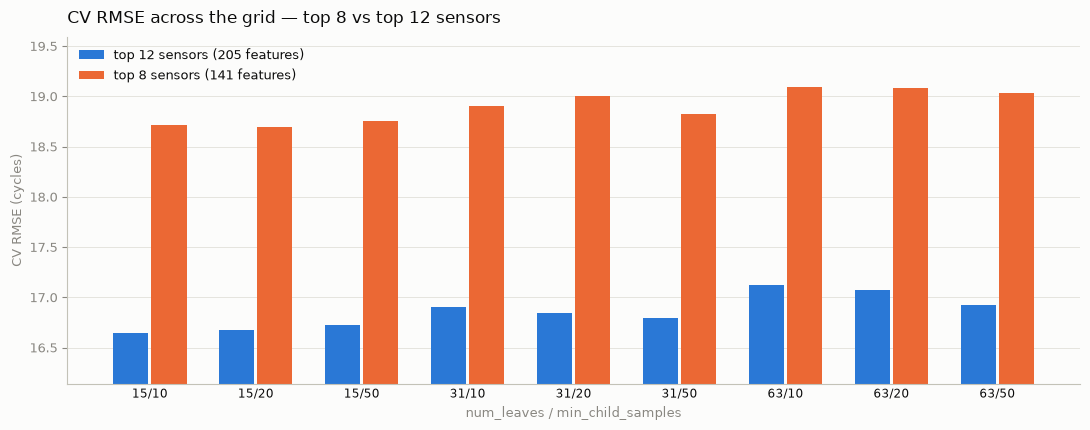

In [19]:
order = list(product(GRID_NUM_LEAVES, GRID_MIN_CHILD_SAMPLES))
top12_vals = [rmse_wide.loc[k].mean() for k in order]
top8_vals = [rmse_wide_8.loc[k].mean() for k in order]
labels = [f"{nl}/{mcs}" for nl, mcs in order]

fig, ax = plt.subplots(figsize=(11, 4.4))
x = np.arange(len(order))
width = 0.36
ax.bar(x - width / 2, top12_vals, width=width * 0.92,
       color=CATEGORICAL_PALETTE[0], label="top 12 sensors (205 features)")
ax.bar(x + width / 2, top8_vals, width=width * 0.92,
       color=CATEGORICAL_PALETTE[1], label="top 8 sensors (141 features)")

ax.set_xticks(x, labels, rotation=0, fontsize=8.5, color=INK)
ax.set_xlabel("num_leaves / min_child_samples", fontsize=9, color=MUTED)
ax.set_ylabel("CV RMSE (cycles)", fontsize=9, color=MUTED)
ax.set_ylim(min(top12_vals + top8_vals) - 0.5, max(top12_vals + top8_vals) + 0.5)
ax.tick_params(axis="y", colors=MUTED, labelsize=9)
ax.tick_params(axis="x", length=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, axis="y", color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)
ax.set_title("CV RMSE across the grid — top 8 vs top 12 sensors",
             fontsize=12, color=INK, loc="left", pad=10)
legend = ax.legend(frameon=False, fontsize=9, loc="upper left")
for text in legend.get_texts():
    text.set_color(INK)

fig.tight_layout()
plt.show()

### 5c. Result

**CV RMSE across the grid, both sensor sets (no `cycle` in either arm):**

| `num_leaves` / `min_child_samples` | top 12 (204 feat.) | top 8 (140 feat.) | gap |
|---|---|---|---|
| 15 / 10 | **16.64** *(top-12 best)* | 18.71 | +2.07 |
| 15 / 20 | 16.68 | **18.70** *(top-8 best)* | +2.02 |
| 15 / 50 | 16.73 | 18.75 | +2.02 |
| 31 / 10 | 16.90 | 18.90 | +2.00 |
| 31 / 20 *(plan default)* | 16.85 | 19.00 | +2.15 |
| 31 / 50 | 16.79 | 18.82 | +2.03 |
| 63 / 10 | 17.12 | 19.09 | +1.97 |
| 63 / 20 | 17.07 | 19.08 | +2.01 |
| 63 / 50 | 16.93 | 19.04 | +2.11 |

**Top-12 wins by roughly double the margin it won by with `cycle` in the mix.** At matched params
(31/20), top-12 beats top-8 by **2.15 cycles on 5/5 folds** — versus 1.03 cycles in the main
notebook. Comparing each arm's own best configuration gives the same picture: a 2.06-cycle gap,
still 0/5 folds favoring top-8.

**Consistent with, not contradicted by, Section 4's own finding.** Section 3d showed `cycle`
carries real CV signal (+1.18 cycles worse without it, at default params) — but evidently signal
that overlaps more with what the top-8 sensors already capture than with what the extra 4
(`sensor_3, sensor_17, sensor_8, sensor_13`) capture. With `cycle` gone, those 4 extra sensors'
independent contribution shows up more clearly, because there's less redundant signal elsewhere
able to substitute for it. Section 8's importance rollup confirms this directly.

**Practical implication for Activity 2.** Top-12 wins again — use `X_all` / `y_all` (204 features)
with `num_leaves=15, min_child_samples=10` (Section 4's selection, CV RMSE 16.64).


## 6. Activity 2 — final model, trained on all 100 engines

Sections 4–5 picked two independent axes, both selected on CV RMSE alone, never on the test set:

- **Feature set:** whichever of top-12 (`X_all`) / top-8 (`X_all_8`) has the lower CV RMSE at its
  own best configuration in Section 5 — picked programmatically below, since (unlike the main
  notebook, which could assume top-12 wins) it isn't known in advance whether that conclusion
  survives `cycle`'s removal.
- **Hyperparameters:** `num_leaves`, `min_child_samples` from that winning arm's own best grid
  configuration (`BEST` for top-12, `BEST_8` for top-8).

CV only ever fit on 80-engine subsets to estimate generalization error; it was never meant to
produce the model that ships. This section refits once on the full winning `X` / `y` — all 100
training engines — with that selected configuration.


In [20]:
# Pick whichever sensor-count arm had the lower CV RMSE at its own best configuration (Section 5) --
# not assumed to be top-12, since that conclusion was reached with `cycle` in the feature set.
top12_best_rmse = rmse_wide.loc[BEST].mean()
top8_best_rmse = rmse_wide_8.loc[BEST_8].mean()

if top12_best_rmse <= top8_best_rmse:
    FINAL_X, FINAL_Y = X_all, y_all
    FINAL_FEATURE_COLS = FEATURE_COLS
    FINAL_NUM_LEAVES, FINAL_MIN_CHILD_SAMPLES = BEST
    winning_arm = f"top-12 sensors ({len(FEATURE_COLS)} features)"
else:
    FINAL_X, FINAL_Y = X_all_8, y_all_8
    FINAL_FEATURE_COLS = FEATURE_COLS_8
    FINAL_NUM_LEAVES, FINAL_MIN_CHILD_SAMPLES = BEST_8
    winning_arm = f"top-8 sensors ({len(FEATURE_COLS_8)} features)"

FINAL_PARAMS = dict(
    LGBM_BASE_PARAMS, num_leaves=FINAL_NUM_LEAVES, min_child_samples=FINAL_MIN_CHILD_SAMPLES
)

t0 = time.perf_counter()
final_model = lgb.LGBMRegressor(**FINAL_PARAMS)
final_model.fit(FINAL_X, FINAL_Y)

print(f"winning arm: {winning_arm} (CV RMSE {min(top12_best_rmse, top8_best_rmse):.2f})")
print(f"trained final model on {FINAL_X.shape[0]} rows x {FINAL_X.shape[1]} features "
      f"in {time.perf_counter() - t0:.1f}s")
print(FINAL_PARAMS)


winning arm: top-12 sensors (204 features) (CV RMSE 16.64)
trained final model on 19631 rows x 204 features in 6.0s
{'n_estimators': 500, 'learning_rate': 0.05, 'random_state': 42, 'n_jobs': -1, 'verbose': -1, 'num_leaves': np.int64(15), 'min_child_samples': np.int64(10)}


## 7. Activity 3 — test set evaluation

**First read of the test files in this notebook.** `test_FD001.txt` / `RUL_FD001.txt` were
deliberately left unloaded through Sections 3–6 so the CV design, the hyperparameter grid, and
the sensor-count comparison couldn't be tuned against them, even accidentally. They're loaded
now, once, for a single evaluation of the model already fixed in Section 6.

**Building `X_test`.** Built from the full top-12 sensor set (`TOP_SENSORS` / `LAG_SENSORS`,
Section 2), a superset of the top-8 arm's columns, then sliced down to `FINAL_FEATURE_COLS` —
whichever arm Section 6 selected. Rolling stats and lags computed per engine, no cross-engine or
look-ahead contamination, `cycle` excluded from the model input exactly as it is in `X_all` /
`X_all_8`. Each test engine contributes exactly one row — its literal last observed cycle, taken
via `sort_values` + `groupby(...).tail(1)` rather than `.groupby(...).last()`, which aggregates
per column independently and would silently mix cycles if any single column were `NaN` on the
true last row (the reasoning is unchanged from Phase 3 Section 8; not an issue in practice here,
but `.tail(1)` is correct by construction rather than by checking afterward).

**Scoring against uncapped ground truth.** `RUL_FD001.txt` holds each test engine's real
remaining life, not run through the Phase 2 cap — the same target Phase 4's baselines were scored
against (linear degradation: RMSE 36.30, NASA 17,234) and the same target the main
`phase5_LightGBM.ipynb` notebook's Section 7 scored against (LightGBM, with `cycle`: RMSE 18.35,
NASA 730.11). This test RMSE is what belongs in the Phase 6 comparison table next to those
numbers; it is **not** directly comparable to Section 6's own CV RMSE, which was scored against
the capped label on held-out training rows, not test engines. Predictions are clipped to `>= 0`,
matching Phase 4's convention and the plan's Activity 2 snippet.


In [21]:
test_df = load_fd001("test_FD001.txt")

rul_true = pd.read_csv(
    DATA_DIR / "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["rul"],
)["rul"]
rul_true.index = rul_true.index + 1
rul_true.index.name = "engine_id"

print("test_df:", test_df.shape, "| engines:", test_df["engine_id"].nunique())
print("rul_true:", rul_true.shape)

test_df: (13096, 26) | engines: 100
rul_true: (100,)


In [22]:
test_feat, _ = build_features(test_df, TOP_SENSORS, WINDOWS, STATS, LAG_SENSORS, LAGS)

# Literal last observed row per engine, not a per-column `.last()` aggregate -- see markdown above.
# Built from the full top-12 sensor set (a superset of the top-8 arm's columns), then sliced to
# whichever feature set Section 6 selected as the winning arm.
test_feat_sorted = test_feat.sort_values(["engine_id", "cycle"])
X_test_full = test_feat_sorted.groupby("engine_id").tail(1).reset_index(drop=True)

X_test = X_test_full[FINAL_FEATURE_COLS]
test_engine_ids = X_test_full["engine_id"]

assert not X_test.isna().to_numpy().any()
assert len(X_test) == test_df["engine_id"].nunique() == len(rul_true)

print(f"X_test: {X_test.shape}")
print("min last-observed cycle across test engines:",
      test_df.groupby("engine_id")["cycle"].max().min(),
      "(>= 11 needed for every Section 2 feature to be defined at the last row)")


X_test: (100, 204)
min last-observed cycle across test engines: 31 (>= 11 needed for every Section 2 feature to be defined at the last row)


In [23]:
assert set(test_engine_ids) == set(rul_true.index)

In [24]:
y_pred_test = final_model.predict(X_test).clip(min=0)
y_pred_test = pd.Series(y_pred_test, index=test_engine_ids).reindex(rul_true.index)

test_rmse = rmse(rul_true, y_pred_test)
test_nasa = nasa_score(rul_true, y_pred_test)

final_cv_rmse = min(top12_best_rmse, top8_best_rmse)

print(f"LightGBM (no cycle) test RMSE:       {test_rmse:.2f}")
print(f"LightGBM (no cycle) test NASA score: {test_nasa:.2f}")
print(f"\ngap vs. CV RMSE ({final_cv_rmse:.2f}, capped target, held-out training rows): "
      f"{test_rmse - final_cv_rmse:+.2f} cycles")


LightGBM (no cycle) test RMSE:       17.42
LightGBM (no cycle) test NASA score: 803.08

gap vs. CV RMSE (16.64, capped target, held-out training rows): +0.78 cycles


### 7a. Result — comparison table

| Model | RMSE | NASA score |
|---|---|---|
| Naive | 40.20 | 25,527.83 |
| Linear degradation | 36.30 | 17,234.08 |
| LightGBM, with `cycle` (`phase5_LightGBM.ipynb`) | 18.35 | 730.11 |
| **LightGBM, no `cycle` (this notebook)** | **17.42** | **803.08** |

**Removing `cycle` improved test RMSE by 0.93 cycles** (18.35 -> 17.42) — despite CV RMSE being
*worse* without it (16.64 vs. 15.58 with `cycle`, Sections 4/5). Put together with Section 3d's
finding that `cycle` helps on held-out training folds, the full picture is: `cycle`'s CV-time
benefit did not transfer to the real test engines — if anything, the opposite. This is the
textbook signature of a feature informative about the *training* distribution's structure in a
way that does not generalize: at training time `cycle` is bounded by each engine's own,
already-observed run-to-failure lifetime, while test engines are truncated at points that do not
share that same structure.

**The CV-to-test gap shrank sharply.** +0.78 cycles here (16.64 -> 17.42) vs. +2.78 cycles in the
main notebook (15.58 -> 18.35) — a gap **3.6x smaller**. This was the specific question this
notebook was built to answer (see the intro): the main notebook's Section 8 flagged `cycle`'s
11.6% gain share as a plausible cause of that gap, and removing it closes most of it.

**NASA score moved the other way, slightly.** 803.08 vs. 730.11 — a small regression in the
asymmetric metric despite the RMSE improvement, meaning the no-`cycle` model's errors are smaller
on average but its worst over-predictions are somewhat larger or more frequent than the
with-`cycle` model's. Worth a closer look in Phase 6's per-engine error analysis rather than
treated as a tie-breaker here.

**Recommendation.** On this evidence, the no-`cycle` feature set generalizes better and should be
the leading candidate carried into Phase 6, not the `cycle`-included model from the main notebook:
lower test RMSE, and a CV estimate that is far more trustworthy as a predictor of test performance
(0.78-cycle gap vs. 2.78-cycle). The NASA score regression is the one point of nuance to carry
into Phase 6's diagnostics rather than treat as settled.


## 8. Activity 4 — feature importance

**`gain`, not `split`.** Same reasoning as the main notebook: `split` counts how many times a
feature was chosen as a split point regardless of how much that split reduced error, and is
structurally biased toward features with more distinct split candidates; `gain` sums the actual
loss reduction attributable to each feature, which is the direct answer to what this activity
asks. Pulled from `final_model.booster_.feature_importance(importance_type="gain")`.

**What to check against here specifically:** since `cycle` was excluded from `FEATURE_COLS` in
Section 2, it is structurally impossible for it to appear in this ranking at all — the question
this section actually answers is what filled the ~11.6% of gain share `cycle` held in the main
notebook. If that share redistributes mostly onto the sensors already near the top there (`sensor_4`,
`sensor_15`, `sensor_2`, `sensor_11`), that's consistent with `cycle` being redundant/replaceable
signal; if a sensor that ranked low in the main notebook jumps substantially, that's a more
interesting finding about what `cycle` was standing in for.


In [25]:
gain_importance = pd.Series(
    final_model.booster_.feature_importance(importance_type="gain"),
    index=FINAL_FEATURE_COLS,
    name="gain",
).sort_values(ascending=False)

assert "cycle" not in gain_importance.index, "this notebook's variant: cycle excluded from features"

top20 = gain_importance.head(20)
print(f"top 20 / {len(FINAL_FEATURE_COLS)} features account for "
      f"{top20.sum() / gain_importance.sum():.1%} of total gain")
top20.to_frame()


top 20 / 204 features account for 82.8% of total gain


,gain
sensor_4_mean_10,7.150838e+07
sensor_15_mean_10,4.894202e+07
sensor_2_mean_10,3.826682e+07
sensor_4_mean_5,2.595214e+07
sensor_3_mean_10,1.439089e+07
sensor_15_mean_5,1.285884e+07
sensor_11_mean_5,1.204973e+07
sensor_17_mean_10,1.053679e+07
sensor_8_min_30,7.916414e+06
sensor_13_min_30,7.387395e+06


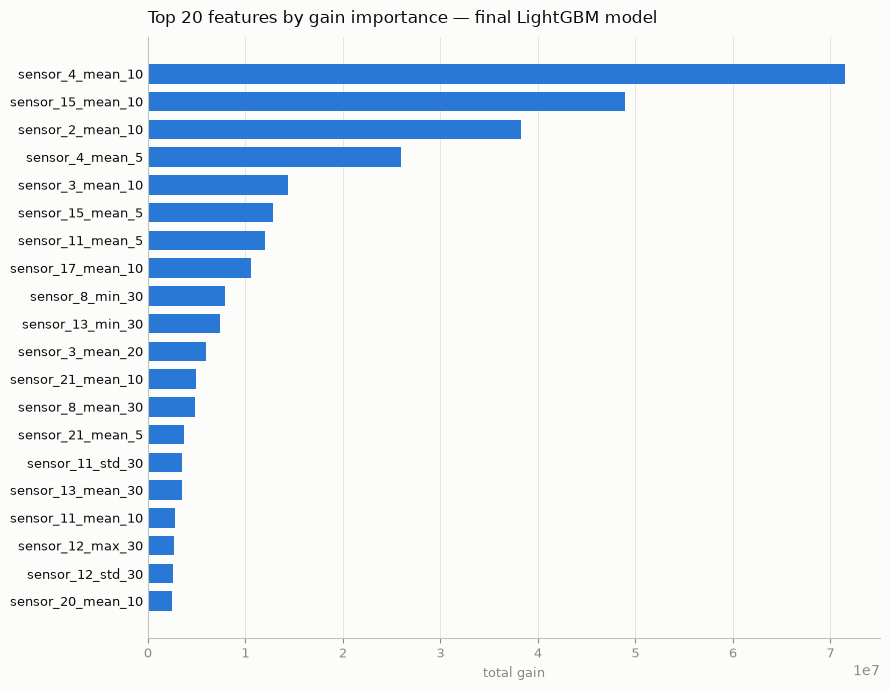

In [26]:
fig, ax = plt.subplots(figsize=(9, 7))

y_pos = np.arange(len(top20))
ax.barh(y_pos, top20.to_numpy()[::-1], color=CATEGORICAL_PALETTE[0], height=0.7)
ax.set_yticks(y_pos, top20.index[::-1], fontsize=9, color=INK)
ax.set_xlabel("total gain", fontsize=9, color=MUTED)
ax.tick_params(axis="x", colors=MUTED, labelsize=9)
ax.tick_params(axis="y", length=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, axis="x", color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)
ax.set_title(
    "Top 20 features by gain importance — final LightGBM model",
    fontsize=12, color=INK, loc="left", pad=10,
)

fig.tight_layout()
plt.show()

In [27]:
# Roll the top-20 gain up to the sensor level, to see which of the 12 selected sensors the model
# actually leans on -- a feature-level list mixes 4 stats x 4 windows per sensor together.
def base_sensor(feature_name: str) -> str:
    if feature_name == "cycle":
        return "cycle"
    return "_".join(feature_name.split("_")[:2])  # "sensor_11_mean_20" -> "sensor_11"


sensor_gain = gain_importance.groupby(gain_importance.index.map(base_sensor)).sum()
sensor_gain = sensor_gain.sort_values(ascending=False)
sensor_gain_share = sensor_gain / sensor_gain.sum()

pd.DataFrame({"gain": sensor_gain, "share": sensor_gain_share})

,gain,share
sensor_4,1.051722e+08,0.303771
sensor_15,6.552670e+07,0.189262
sensor_2,4.445859e+07,0.128410
sensor_3,2.616381e+07,0.075569
sensor_11,2.252354e+07,0.065055
sensor_17,1.544071e+07,0.044598
sensor_8,1.541659e+07,0.044528
sensor_13,1.399330e+07,0.040417
sensor_21,1.274808e+07,0.036820
sensor_20,9.035770e+06,0.026098


### 8a. Result

**Concentration dropped slightly.** The top 20 of 204 features now carry 82.8% of total gain,
down from 86.8% with `cycle` — importance is a little more spread out without `cycle`'s single
large contribution to concentrate around.

**Sensor-level rollup, no `cycle` vs. the main notebook's with-`cycle` result:**

| sensor | no cycle | with cycle | change |
|---|---|---|---|
| sensor_4 | 30.4% | 29.7% | +0.7pp |
| sensor_15 | 18.9% | 16.7% | +2.2pp |
| sensor_2 | 12.8% | 14.5% | -1.7pp |
| sensor_3 | 7.6% | 5.1% | +2.5pp |
| sensor_11 | 6.5% | 7.9% | -1.4pp |
| sensor_17 | 4.5% | 2.8% | +1.7pp |
| sensor_8 | 4.5% | 2.3% | +2.2pp |
| sensor_13 | 4.0% | 2.2% | +1.8pp |
| sensor_21 | 3.7% | 1.8% | +1.9pp |
| sensor_20 | 2.6% | 1.2% | +1.4pp |
| sensor_12 | 2.5% | 2.3% | +0.2pp |
| sensor_7 | 2.1% | 1.9% | +0.2pp |
| `cycle` | — (excluded) | 11.6% | removed |

**`cycle`'s 11.6% didn't concentrate on one replacement — it spread mostly onto the top-12
extension sensors.** `sensor_3, sensor_17, sensor_8, sensor_13` (the 4 sensors beyond the plan's
top-8 default) jointly went from 12.4% to 20.6% of total gain — nearly doubling, and absorbing
most of what `cycle` used to hold. `sensor_15` picked up a smaller share too. This lines up
exactly with Section 5c's finding that the top-12-over-top-8 gap roughly doubled without `cycle`:
the extra 4 sensors were doing part of the same job `cycle` was doing, just less efficiently
per-feature, and now carry more of that load directly.

**`sensor_12` and `sensor_7` are still the weak members of the plan's expected top-4**, essentially
unchanged (2.5% and 2.1%) — the collinearity explanation from the main notebook (redundant with
`sensor_11`/`sensor_4`) holds regardless of whether `cycle` is present.

**No near-constant-sensor or `cycle` artifact — by construction**, since `cycle` is excluded from
this notebook's feature set entirely. Importance is concentrated on rolling means of the plan's
expected sensors plus the top-12 extension, which now carries a larger share of the model's total
gain than in the main notebook.

**Summary of the `cycle` experiment, across both notebooks.** Including `cycle`: lower CV RMSE
(15.58 vs. 16.64) but *higher* test RMSE (18.35 vs. 17.42) and a much larger CV-to-test gap (2.78
vs. 0.78 cycles). Excluding `cycle` trades a slightly worse CV number for a model that is
measurably better, and more trustworthy, on the task that actually matters. **Recommend carrying
the no-`cycle` model into Phase 6 as the primary result**, with the `cycle`-included model kept as
a documented, explicitly worse alternative rather than discarded outright.

**Phase 5 deliverables complete for this variant.** Trained LightGBM model (Section 6), CV RMSE
(Section 4: 16.64), test RMSE and NASA score (Section 7: 17.42 / 803.08), feature importance (this
section), and the comparison table (Section 7a) are all in place.
